<a href="https://colab.research.google.com/github/Pinkraaaa/Lab_3/blob/main/Lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Running on: cuda



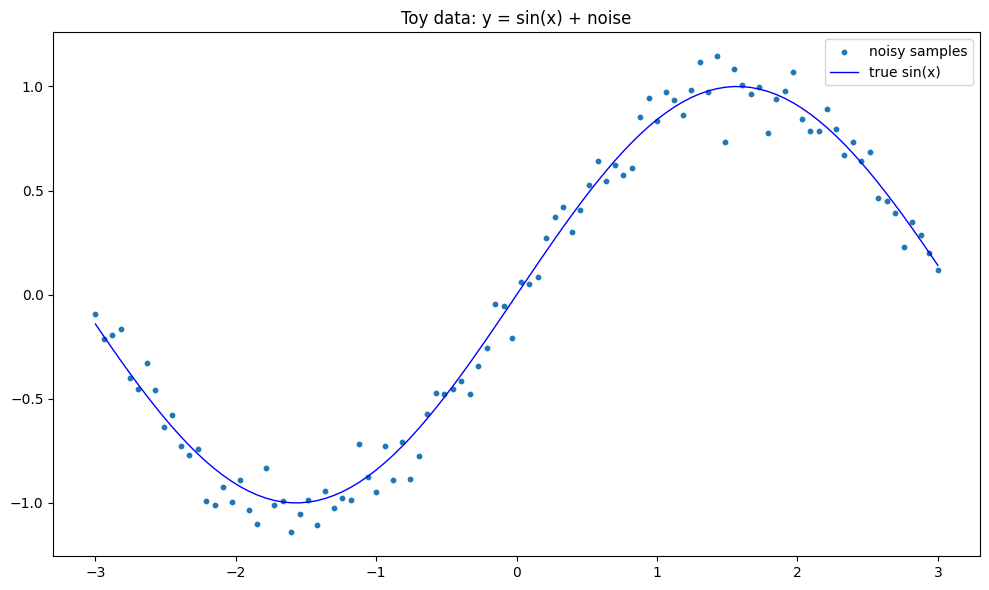


Final params: w = 0.34, b = -0.01, final loss = 0.20



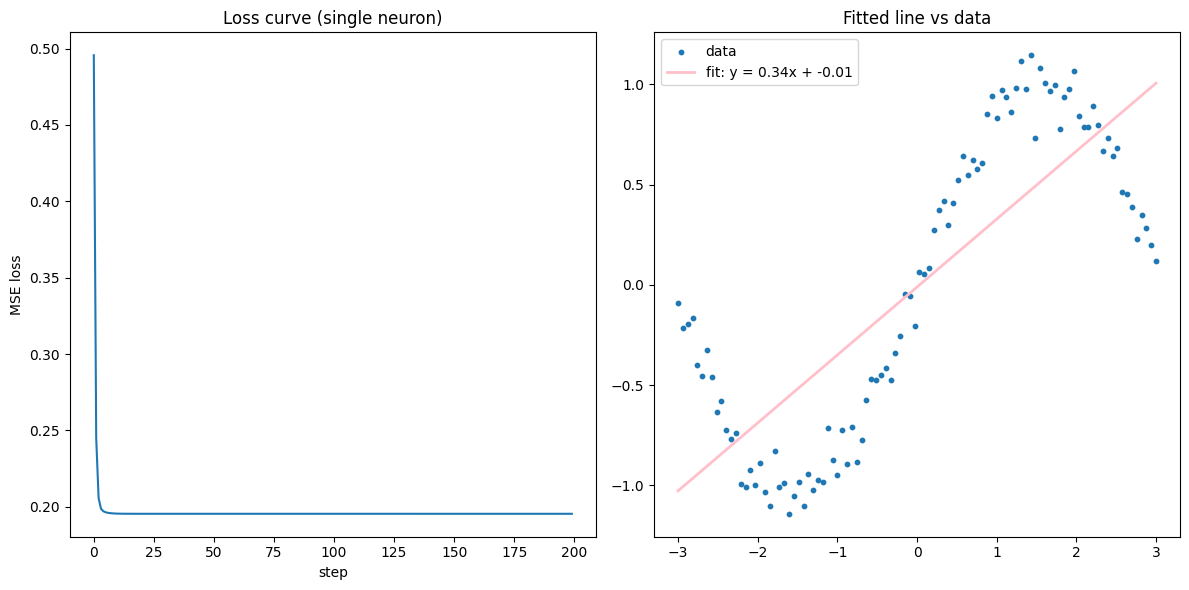

In [47]:
#PART 0 AND 1.1
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)
print()


#PART 1.1
# TODO: Generate the toy data
#   x = np.linspace(-3, 3, 100); y = np.sin(x) + small Gaussian noise (std=0.1)
#   Plot it.

np.random.seed(RANDOM_STATE)
x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, size = x.shape)

plt.figure(figsize=(10, 6))
plt.scatter(x, y, s = 10, label = "noisy samples")
plt.plot(x, np.sin(x), color = "blue", lw = 1, label = "true sin(x)")
plt.title("Toy data: y = sin(x) + noise")
plt.legend()
plt.tight_layout()
plt.show()


# TODO: Initialise w and b to small random values.

rng = np.random.default_rng(RANDOM_STATE)
w = rng.normal(0, 0.1)
b = rng.normal(0, 0.1)

# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
#   y_hat = w * x + b
#   loss  = np.mean((y_hat - y) ** 2)               # MSE
#   dw    = np.mean(2 * (y_hat - y) * x)            # dLoss/dw  (derive this on paper!)
#   db    = np.mean(2 * (y_hat - y))                # dLoss/db
#   w    -= lr * dw
#   b    -= lr * db
#   Record the loss at every step.

# TODO: Plot (a) the loss curve over the 200 steps
lr = 0.1
n_steps = 200
losses = []

for step in range(n_steps):
    y_hat = w * x + b
    loss = np.mean((y_hat - y) ** 2)          #MSE
    losses.append(loss)

    dw = np.mean(2 * (y_hat - y) * x)         #dLoss/dw
    db = np.mean(2 * (y_hat - y))             #dLoss/db

    w -= lr * dw
    b -= lr * db

print()
print(f"Final params: w = {w:.2f}, b = {b:.2f}, final loss = {losses[-1]:.2f}")

fig, axes = plt.subplots(1, 2, figsize = (12, 6))
axes[0].plot(losses)
axes[0].set_title("Loss curve (single neuron)")
axes[0].set_xlabel("step")
axes[0].set_ylabel("MSE loss")
print()



#(b) the data with the fitted line on top.
axes[1].scatter(x, y, s = 10, label = "data")
axes[1].plot(x, w * x + b, color = "pink", lw = 2, label = f"fit: y = {w:.2f}x + {b:.2f}")
axes[1].set_title("Fitted line vs data")
axes[1].legend()
plt.tight_layout()
plt.show()




PART 1.2: HIDDEN LAYERS AND ACTIVATION: WHY DEPTHS HELPS

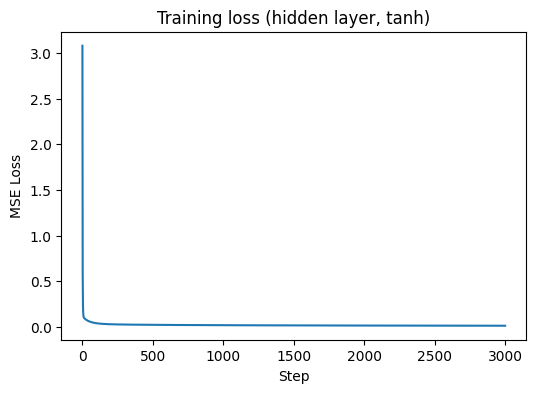

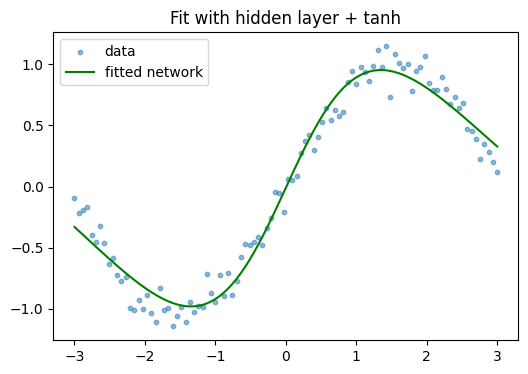

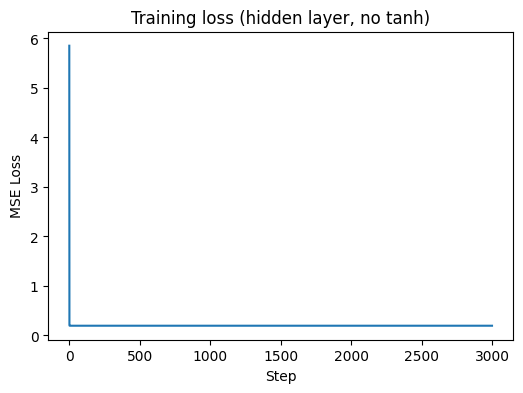

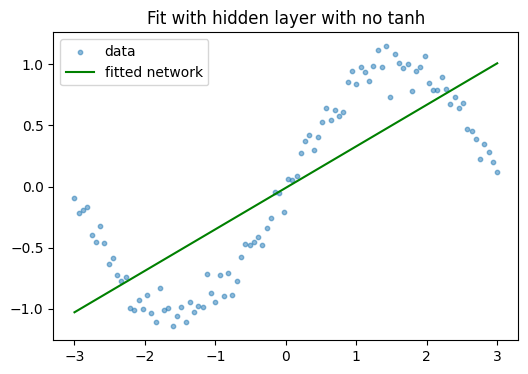

In [48]:
#PART 1.2
# TODO: Initialise parameters
#   W1: shape (1, 8),  b1: shape (8,)
#   W2: shape (8, 1),  b2: shape (1,)
#   Small random values (e.g. np.random.randn(...) * 0.5)
np.random.seed(RANDOM_STATE)
W1 = np.random.randn(1, 8) * 0.5
b1 = np.zeros(8)
W2 = np.random.randn(8, 1) * 0.5
b2 = np.zeros(1)

x_col = x.reshape(-1, 1)   # (100, 1) so matrix multiply works
y_col = y.reshape(-1, 1)   # (100, 1)

lr = 0.05
steps = 3000
losses = []


# TODO: Forward pass (keep the intermediate values — you need them for backprop):
#   z1 = x @ W1 + b1        # pre-activation, shape (100, 8)
#   h  = np.tanh(z1)        # activation
#   y_hat = h @ W2 + b2     # output, shape (100, 1)
#   loss  = np.mean((y_hat - y) ** 2)

for step in range(steps):
    # ---- forward pass ----
    z1 = x_col @ W1 + b1        # (100, 8)
    h = np.tanh(z1)              # (100, 8)
    y_hat = h @ W2 + b2          # (100, 1)

    loss = np.mean((y_hat - y_col) ** 2)
    losses.append(loss)

# TODO: Backward pass (the chain rule, layer by layer):
#   d_yhat = 2 * (y_hat - y) / len(y)
#   dW2 = h.T @ d_yhat ;  db2 = d_yhat.sum(axis=0)
#   dh  = d_yhat @ W2.T
#   dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
#   dW1 = x.T @ dz1 ;  db1 = dz1.sum(axis=0)

# ---- backward pass ----
    d_yhat = 2 * (y_hat - y_col) / len(y_col)   # (100, 1)
    dW2 = h.T @ d_yhat                           # (8, 1)
    db2 = d_yhat.sum(axis=0)                     # (1,)

    dh = d_yhat @ W2.T                           # (100, 8)
    dz1 = dh * (1 - np.tanh(z1) ** 2)            # (100, 8)
    dW1 = x_col.T @ dz1                          # (1, 8)
    db1 = dz1.sum(axis=0)

# TODO: Update all parameters with learning rate lr, loop for ~3000 steps,
#   record the loss.
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2



# TODO: Plot the loss curve AND the final fit over the data.
#   Then re-run with the tanh REMOVED (h = z1). What happens to the fit?

plt.figure(figsize = (6, 4))
plt.plot(losses)
plt.xlabel("Step")
plt.ylabel("MSE Loss")
plt.title("Training loss (hidden layer, tanh)")
plt.show()


plt.figure(figsize = (6, 4))
plt.scatter(x, y, s = 10, label = "data", alpha = 0.5)
plt.plot(x, y_hat, color = "green", label = "fitted network")
plt.legend()
plt.title("Fit with hidden layer + tanh")
plt.show()



#RE-RUN WITHOUT TANH
np.random.seed(RANDOM_STATE)
W1 = np.random.randn(1, 8) * 0.5
b1 = np.zeros(8)
W2 = np.random.randn(8, 1) * 0.5
b2 = np.zeros(1)

x_col = x.reshape(-1, 1)   # (100, 1) so matrix multiply works
y_col = y.reshape(-1, 1)   # (100, 1)

lr = 0.05
steps = 3000
losses = []


for step in range(steps):
    # ---- forward pass ----
    z1 = x_col @ W1 + b1
    h = z1                      # No tanh this time
    y_hat = h @ W2 + b2

    loss = np.mean((y_hat - y_col) ** 2)
    losses.append(loss)

    # ---- backward pass ----
    d_yhat = 2 * (y_hat - y_col) / len(y_col)   # (100, 1)
    dW2 = h.T @ d_yhat                           # (8, 1)
    db2 = d_yhat.sum(axis=0)                     # (1,)

    dh = d_yhat @ W2.T                           # (100, 8)
    dz1 = dh                                      # No tanh this time
    dW1 = x_col.T @ dz1                          # (1, 8)
    db1 = dz1.sum(axis=0)

    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2



plt.figure(figsize = (6, 4))
plt.plot(losses)
plt.xlabel("Step")
plt.ylabel("MSE Loss")
plt.title("Training loss (hidden layer, no tanh)")
plt.show()


plt.figure(figsize = (6, 4))
plt.scatter(x, y, s = 10, label = "data", alpha = 0.5)
plt.plot(x, y_hat, color = "green", label = "fitted network")
plt.legend()
plt.title("Fit with hidden layer with no tanh")
plt.show()






PART 1.3 -- THE LEARNING RATE: TOO COLD, TOO HOT, JUST RIGHT

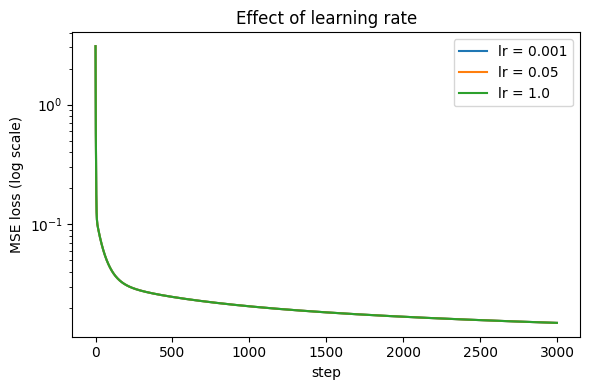

In [49]:
# TODO: Wrap your Part 1.2 training loop in a function train_toy(lr, steps=3000)
#   that returns the list of losses.

def train_toy(lr, steps = 3000):
  np.random.seed(RANDOM_STATE)
  W1 = np.random.randn(1, 8) * 0.5
  b1 = np.zeros(8)
  W2 = np.random.randn(8, 1) * 0.5
  b2 = np.zeros(1)

  x_col = x.reshape(-1, 1)   # (100, 1) so matrix multiply works
  y_col = y.reshape(-1, 1)   # (100, 1)

  lr = 0.05
  steps = 3000
  losses = []


  for step in range(steps):
      # ---- forward pass ----
      z1 = x_col @ W1 + b1
      h = np.tanh(z1)                      # No tanh this time
      y_hat = h @ W2 + b2

      loss = np.mean((y_hat - y_col) ** 2)
      losses.append(loss)

      # ---- backward pass ----
      d_yhat = 2 * (y_hat - y_col) / len(y_col)   # (100, 1)
      dW2 = h.T @ d_yhat                           # (8, 1)
      db2 = d_yhat.sum(axis=0)                     # (1,)

      dh = d_yhat @ W2.T                           # (100, 8)
      dz1 = dh * (1 - np.tanh(z1) ** 2)            # No tanh this time
      dW1 = x_col.T @ dz1                          # (1, 8)
      db1 = dz1.sum(axis=0)

      W1 -= lr * dW1
      b1 -= lr * db1
      W2 -= lr * dW2
      b2 -= lr * db2

  return losses


#TODO: Run it with THREE learning rates, e.g. lr = 0.001, 0.05, 1.0
#   (keep the same initial weights for a fair comparison — reset the seed).

lrs = [0.001, 0.05, 1.0]
results = {}

for lr in lrs:
  results[lr] = train_toy(lr, steps = 3000)

# TODO: Plot the three loss curves on the same axes (log scale on y helps), with a legend.

plt.figure(figsize = (6, 4))
for lr, losses in results.items():
    plt.plot(losses, label = f"lr = {lr}")
plt.yscale("log")
plt.xlabel("step"); plt.ylabel("MSE loss (log scale)")
plt.title("Effect of learning rate")
plt.legend()
plt.tight_layout()
plt.show()




SECTION 2: A REAL FEEDFORWARD NETWORK IN PYTORCH


Part 2.1 — Preprocess and split (recycled from Lab 2)


In [ ]:
# TODO: Load the obesity dataset (same OBESITY_URL as Lab 2).
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import pandas as pd
import numpy as np # Import numpy for isnan

OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

ob = pd.read_csv(OBESITY_URL)
print("Shape: ", ob.shape)
ob.info()
print("\nMissing values (initial): ", ob.isna().sum().sum())

# TODO: Encode categoricals exactly as you did in Lab 2
#   (binary yes/no -> 0/1; Gender/MTRANS/CAEC/CALC -> your justified choice).
#   Encode the target NObeyesdad into integers 0..6 (LabelEncoder) — CrossEntropyLoss
#   expects integer class indices.

ob_processed = ob.copy()
binary_map = {'yes': 0 , 'no': 1}
for col in ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']:
    ob_processed[col] = ob_processed[col].astype(str).str.lower().map(binary_map)

gender_map = {"male": 0, "female": 1}
ob_processed["Gender"] = ob_processed["Gender"].astype(str).str.lower().map(gender_map)

ob_processed = pd.get_dummies(ob_processed, columns=["MTRANS","CAEC", "CALC"], drop_first = False)

le = LabelEncoder()
ob_processed['NObeyesdad'] = le.fit_transform(ob_processed['NObeyesdad'])
print('\nClass to int mapping:', dict(zip(le.classes_, le.transform(le.classes_))))

# Separate features and target after all transformations and prepare for NaN handling
X = ob_processed.drop(columns=["NObeyesdad"])
y = ob_processed['NObeyesdad'].values

# Handle NaN values that might have been introduced by .map() operations
# (This block should now find 0 NaNs if mapping was exhaustive and data was clean)
print(f"NaNs in X before imputation: {X.isnull().sum().sum()}")
for col in X.columns:
    if X[col].isnull().any(): # Check if there are ANY NaNs in the column
        if X[col].dtype == 'object':
            X[col] = X[col].fillna(X[col].mode()[0])
        else:
            X[col] = X[col].fillna(X[col].mean())
print(f"NaNs in X after imputation: {X.isnull().sum().sum()}")


# Remove constant columns (columns with only one unique value) or columns that are all NaN
constant_or_all_nan_columns = [
    col for col in X.columns
    if X[col].nunique(dropna=True) <= 1 or X[col].isnull().all()
]

if constant_or_all_nan_columns:
    print(f"Removing constant or all-NaN columns: {constant_or_all_nan_columns}")
    X = X.drop(columns=constant_or_all_nan_columns)

# Convert X to numpy array (after all DataFrame-based preprocessing)
X = X.values.astype(float)


# TODO: Stratified train / validation / test split (60/20/20, stratify=y,
#   random_state=RANDOM_STATE).
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size = 0.4, random_state= RANDOM_STATE, stratify = y
)

X_test, X_val, y_test, y_val = train_test_split(
    X_temp, y_temp, test_size = 0.5, random_state = RANDOM_STATE, stratify = y_temp
)


# TODO: Fit a StandardScaler on the TRAINING set only; transform all three splits.
#   (Neural networks are far more sensitive to feature scale than random forests —
#    remember Section 1, where all gradients depended on x!)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s= scaler.transform(X_val)
X_test_s = scaler.transform(X_test)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]} | Val: {X_val.shape[0]}")




# TODO: Convert to tensors and wrap in DataLoaders:
#   X -> torch.float32, y -> torch.long
#   train_loader (batch_size=32, shuffle=True), val_loader, test_loader

def to_tensors(X, y):
    X_t = torch.tensor(X, dtype = torch.float32)
    y_t = torch.tensor(y, dtype = torch.long)
    return X_t, y_t

X_train_t, y_train_t = to_tensors(X_train_s, y_train)
X_val_t, y_val_t = to_tensors(X_val_s, y_val)
X_test_t, y_test_t = to_tensors(X_test_s, y_test)

train_ds = TensorDataset(X_train_t, y_train_t)
val_ds = TensorDataset(X_val_t, y_val_t)
test_ds = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

print("Number of features going into the network விரிவா: ", X_train_s.shape[1])

In [51]:
print("Shape going into scaler:", X_train.shape)
print("Any NaN going into scaler:", np.isnan(X_train).any())
print("Any column entirely NaN:", np.isnan(X_train).all(axis=0).any())

Shape going into scaler: (1266, 26)
Any NaN going into scaler: False
Any column entirely NaN: False


PART 2.2: DESIGN THE NETWORK

An MLP: input -> hidden layers with ReLU -> 7 output logits.

In [52]:
# TODO: Define a FeedForwardNet class (subclass nn.Module) with:
#   - constructor args: input_dim, hidden_sizes=(64, 32), n_classes=7
#   - at least TWO hidden layers with ReLU activations
#   - output layer producing 7 raw logits
#     (NO softmax — nn.CrossEntropyLoss applies log-softmax internally)

# class FeedForwardNet(nn.Module):
#     def __init__(self, ...):
#         ...
#     def forward(self, x):
#         ...

class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes = (64, 32), n_classes = 7):
        super().__init__()

        layers = []
        prev_size = input_dim

        for size in hidden_sizes:
            layers.append(nn.Linear(prev_size, size))
            layers.append(nn.ReLU())  #Activation function
            prev_size = size

        #for the output layer
        layers.append(nn.Linear(prev_size, n_classes))
        self.net = nn.Sequential(*layers)


    def forward(self, x):
      return self.net(x)


# TODO: Instantiate, move to DEVICE, print the model.

input_dim = X_train_s.shape[1]

model = FeedForwardNet(input_dim = input_dim, hidden_sizes = (64, 32), n_classes = 7)
model = model.to(DEVICE)
print(model)

# TODO: Count trainable parameters:
#   sum(p.numel() for p in model.parameters() if p.requires_grad)
#   Verify the count for the FIRST layer by hand: input_dim * 64 + 64.

print()
print()
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Total trainable parameters:", n_params)

first_layer_params = input_dim * 64 + 64
print("First layer, by hand:", first_layer_params)



FeedForwardNet(
  (net): Sequential(
    (0): Linear(in_features=26, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=7, bias=True)
  )
)


Total trainable parameters: 4039
First layer, by hand: 1728


PART 2.3: THE TRAINING LOOP

The same loop you built by hand in Section 1 — now with autograd, an optimizer, and batches.

In [ ]:
# TODO: criterion = nn.CrossEntropyLoss()
#       optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)   # or SGD — justify

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)   # or SGD — justify


# TODO: Train for at least 50 epochs. Each epoch:
#   1. model.train(); for xb, yb in train_loader:
#        optimizer.zero_grad()
#        logits = model(xb.to(DEVICE))
#        loss = criterion(logits, yb.to(DEVICE))
#        loss.backward()          # <- the backprop you wrote by hand in Part 1.2
#        optimizer.step()         # <- the update rule you wrote in Part 1.1
#   2. model.eval() + torch.no_grad(): compute loss AND accuracy on train and validation sets
#   3. Append everything to history lists; print a one-line summary per epoch.

epochs = 50
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc = -1.0

for epoch in range(epochs):
    model.train()
    r_loss = 0.0
    correct = 0
    total = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        r_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

    train_loss = r_loss / total
    train_acc = correct / total

    model.eval()
    val_r_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss = criterion(logits, yb)

            val_r_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            val_correct += (preds == yb).sum().item()
            val_total += yb.size(0)

    val_loss = val_r_loss / val_total
    val_acc = val_correct / val_total


    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch + 1:2d} / {epochs} | "
          f"train_loss = {train_loss:.4f} train_acc = {train_acc:.4f} | "
          f"val_loss = {val_loss:.4f} val_acc = {val_acc:.4f}")



  # TODO: Save the best model (highest validation accuracy):
#   torch.save(model.state_dict(), "ffn_best.pt")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "ffn_best.pt")

print(f"\nBest validation accuracy: {best_val_acc:.4f}")



# TODO: Plot loss curves (train + val) and accuracy curves (train + val), with legend
plt.figure(figsize=(6, 4))
plt.plot(history["train_loss"], label="train")
plt.plot(history["val_loss"], label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss over training")
plt.legend()
plt.show()

# ---- plot accuracy curves ----
plt.figure(figsize=(6, 4))
plt.plot(history["train_acc"], label="train")
plt.plot(history["val_acc"], label="val")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy over training")
plt.legend()
plt.show()

PART 2.4: EXPERIMENTS: HOW TRAINING CHOICES CHANGE THE OUTCOME

Run three controlled experiments. Change ONE thing at a time; keep everything else fixed.

In [57]:
# Wrap your Part 2.3 loop in a function first:
#   def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
#       ... returns history dict ...

def run_experiment(hidden_sizes = (64, 32), lr = 1e-3, batch_size = 32, epochs = 50, dropout = 0.0):

    train_loader_exp = DataLoader(train_ds, batch_size = batch_size, shuffle = True)
    val_loader_exp = DataLoader(val_ds, batch_size = batch_size, shuffle = False)

    class ExpNet(nn.Module):
        def __init__(self, input_dim, hidden_sizes, n_classes = 7, dropout = 0.0):
            super().__init__()

            layers = []

            prev_size = input_dim

            for size in hidden_sizes:
                layers.append(nn.Linear(prev_size, size))
                layers.append(nn.ReLU())

                if dropout > 0:
                    layers.append(nn.Dropout(dropout))
                prev_size = size
            layers.append(nn.Linear(prev_size, n_classes))
            self.net = nn.Sequential(*layers)

        def forward(self, x):
            return self.net(x)

    exp_model = ExpNet(input_dim, hidden_sizes, n_classes=7, dropout=dropout).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(exp_model.parameters(), lr = 1e-3)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        exp_model.train()
        t_loss = 0.0
        t_correct = 0
        t_total = 0

        for xb, yb in train_loader_exp:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = exp_model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            t_loss += loss.item() * xb.size(0)
            t_correct += (logits.argmax(1) == yb).sum().item()
            t_total += yb.size(0)


        exp_model.eval()
        v_loss = 0.0
        v_correct = 0
        v_total = 0

        with torch.no_grad():
            for xb, yb in val_loader_exp:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits = exp_model(xb)
                loss = criterion(logits, yb)
                v_loss += loss.item() * xb.size(0)
                v_correct += (logits.argmax(1) == yb).sum().item()
                v_total += yb.size(0)

        history["train_loss"].append(t_loss / t_total)
        history["val_loss"].append(v_loss / v_total)
        history["train_acc"].append(t_correct / t_total)
        history["val_acc"].append(v_correct / v_total)

    return history



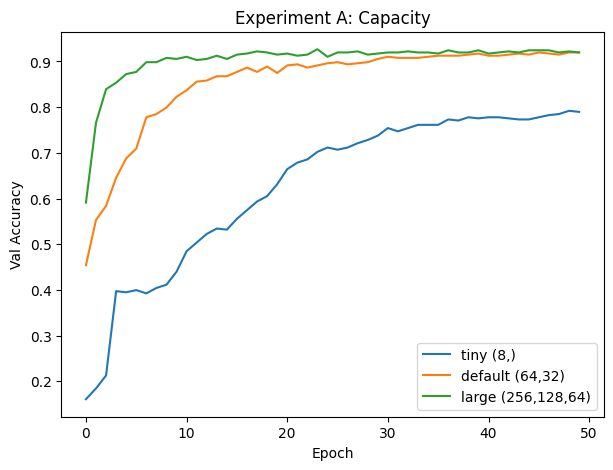

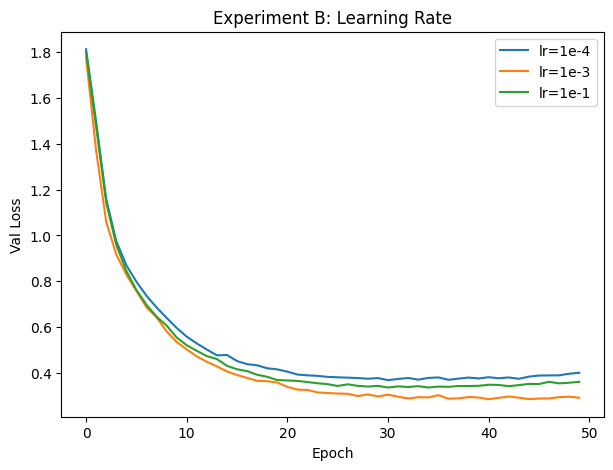

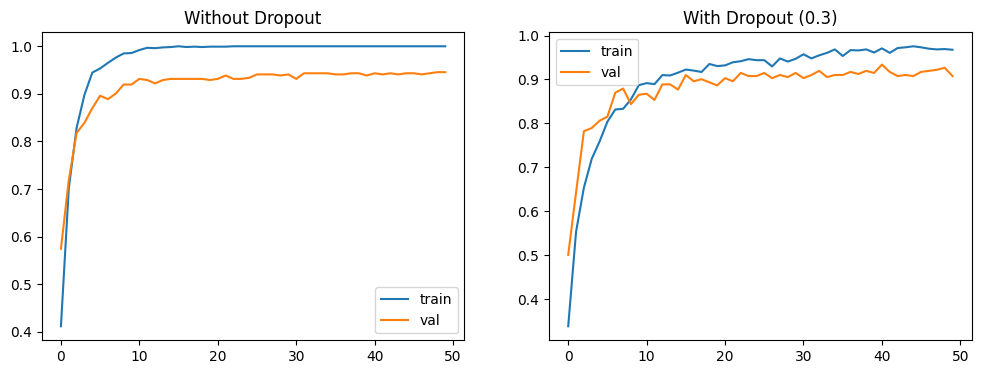

In [59]:
#FIRST EXPERIMENT
#TODO — Experiment A (capacity): tiny (8,) vs default (64, 32) vs large (256, 128, 64).
#   Plot the three validation-accuracy curves together.

h_tiny = run_experiment(hidden_sizes=(8,))
h_default = run_experiment(hidden_sizes=(64, 32))
h_large = run_experiment(hidden_sizes=(256, 128, 64))

plt.figure(figsize=(7, 5))
plt.plot(h_tiny["val_acc"], label="tiny (8,)")
plt.plot(h_default["val_acc"], label="default (64,32)")
plt.plot(h_large["val_acc"], label="large (256,128,64)")
plt.xlabel("Epoch"); plt.ylabel("Val Accuracy"); plt.legend()
plt.title("Experiment A: Capacity")
plt.show()


#SECOND EXPERIMENT
# TODO — Experiment B (learning rate): lr = 1e-4, 1e-3, 1e-1 (same architecture).
#   Plot the three validation-loss curves together. Compare with Part 1.3.

h_lr_low = run_experiment(lr=1e-4)
h_lr_mid = run_experiment(lr=1e-3)
h_lr_high = run_experiment(lr=1e-1)

plt.figure(figsize=(7, 5))
plt.plot(h_lr_low["val_loss"], label="lr=1e-4")
plt.plot(h_lr_mid["val_loss"], label="lr=1e-3")
plt.plot(h_lr_high["val_loss"], label="lr=1e-1")
plt.xlabel("Epoch"); plt.ylabel("Val Loss"); plt.legend()
plt.title("Experiment B: Learning Rate")
plt.show()


#THIRD EXPERIMENT
# TODO — Experiment C (regularization): take your LARGEST network and train it
#   with and without nn.Dropout(0.3) after each hidden layer.
#   Plot train vs validation accuracy for both runs.

h_large_no_dropout = run_experiment(hidden_sizes=(256, 128, 64), dropout=0.0)
h_large_dropout = run_experiment(hidden_sizes=(256, 128, 64), dropout=0.3)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(h_large_no_dropout["train_acc"], label="train")
axes[0].plot(h_large_no_dropout["val_acc"], label="val")
axes[0].set_title("Without Dropout")
axes[0].legend()

axes[1].plot(h_large_dropout["train_acc"], label="train")
axes[1].plot(h_large_dropout["val_acc"], label="val")
axes[1].set_title("With Dropout (0.3)")
axes[1].legend()

plt.show()
